# Algorithms

### Imports

In [464]:
import time
import numpy as np
import matplotlib.pyplot as plt
from typing import Literal
from abc import ABC, abstractmethod
import os
import csv
from datetime import datetime

np.random.seed(12345)

FINE_TUNE_GRASP = 0
FINE_TUNE_AS = 0
FINE_TUNE_MMAS = 0
FINE_TUNE_ACS = 0
FINE_TUNE_AMTS = 0

### Data loading

In [465]:
DistanceMetric = Literal['euclidean', 'manhattan']
def get_dist_function(metric: DistanceMetric):
    if metric == 'euclidean':
        return lambda diff: np.sqrt((diff ** 2).sum(axis=-1))
    elif metric == 'manhattan':
        return lambda diff: np.abs(diff).sum(axis=-1)
    else:
        raise ValueError(f"Invalid metric: {metric}")

#### Capacitated Vehicle Routing Problem (CVRP)

In [466]:
class CvrpInstance:
    """
    Loads a CVRP instance from file.
    Format:
        line 1: vehicle capacity
        line 2 (depot): x, y
        remaining (customers): x, y, demand
    """
    def __init__(self, filepath, metric='euclidean'):
        with open(filepath, 'r') as f:
            lines = [line.strip() for line in f if line.strip()]

        self.filepath = filepath
        self.capacity = int(lines[0])
        self.depot = np.array(lines[1].split(), dtype=float)

        # shape (n, 3): columns are x, y, demand
        self.customers = np.loadtxt(lines[2:])

        # coords[0] = depot, coords[1..n] = customers
        self.coords = np.vstack([self.depot, self.customers[:, :2]])
        # demands[0] = 0 (depot), demands[1..n] = customer demands
        self.demands = np.concatenate([[0.0], self.customers[:, 2]])

        self.get_distance = get_dist_function(metric)
        self.dist_matrix = self._compute_distance_matrix()

    def _compute_distance_matrix(self):
        diff = self.coords[:, np.newaxis, :] - self.coords[np.newaxis, :, :]
        return self.get_distance(diff)
    
    def __repr__(self):
        return f"CvrpInstance(capacity={self.capacity}, depot={self.depot}, n={self.customers.shape[0]}, filepath={self.filepath})"

cvrp_data = CvrpInstance("instances/cvrp.txt")
print(cvrp_data)

CvrpInstance(capacity=160, depot=[30. 40.], n=50, filepath=instances/cvrp.txt)


#### Vehicle Routing Problem with Time Windows (VRPTW):

In [467]:
class VrptwInstance(CvrpInstance):
    """
    Loads a VRPTW instance from file. Extends CvrpInstance.
    Format:
        line 1: num_vehicles, vehicle capacity
        line 2 (depot): x, y
        remaining (customers): x, y, demand, tw_open, tw_close, service_time
    """
    def __init__(self, filepath, metric='euclidean'):
        with open(filepath, 'r') as f:
            lines = [line.strip() for line in f if line.strip()]

        self.filepath = filepath
        header = lines[0].split()
        self.num_vehicles = int(header[0])
        self.capacity = int(header[1])
        self.depot = np.array(lines[1].split(), dtype=float)

        # shape (n, 6): columns are x, y, demand, tw_open, tw_close, service_time
        self.customers = np.loadtxt(lines[2:])

        self.coords = np.vstack([self.depot, self.customers[:, :2]])
        self.demands = np.concatenate([[0.0], self.customers[:, 2]])

        # index 0 = depot (no constraint), 1..n = customers
        self.tw_open = np.concatenate([[0.0], self.customers[:, 3]])
        self.tw_close = np.concatenate([[np.inf], self.customers[:, 4]])
        self.service_time = np.concatenate([[0.0], self.customers[:, 5]])

        self.get_distance = get_dist_function(metric)
        self.dist_matrix = self._compute_distance_matrix()
    
    def __repr__(self):
        return f"VrptwInstance(num_vehicles={self.num_vehicles}, capacity={self.capacity}, depot={self.depot}, n={self.customers.shape[0]}, filepath={self.filepath})"

vrptw_data = VrptwInstance("instances/vrptw.txt")
print(vrptw_data)

VrptwInstance(num_vehicles=25, capacity=200, depot=[35. 35.], n=100, filepath=instances/vrptw.txt)


#### Stoppage criterions

In [468]:
class StoppingCriterion(ABC):
    def reset(self):
        pass
    @abstractmethod
    def should_stop(self, gen: int, history: list[float]) -> bool: ...
    @abstractmethod
    def __repr__(self) -> str: ...


class MaxGenerations(StoppingCriterion):
    def __init__(self, n: int):
        assert n > 0, "n must be > 0"
        self.n = n
    def should_stop(self, gen, history):
        return gen + 1 >= self.n
    def __repr__(self):
        return f"MaxGenerations({self.n})"


class TimeLimit(StoppingCriterion):
    def __init__(self, seconds: float):
        assert seconds > 0, "seconds must be > 0"
        self.seconds = seconds
        self._start = None
    def reset(self):
        self._start = time.monotonic()
    def should_stop(self, gen, history):
        return (time.monotonic() - self._start) >= self.seconds
    def __repr__(self):
        return f"TimeLimit({self.seconds}s)"


class MinImprovement(StoppingCriterion):
    def __init__(self, window: int, min_pct: float = 0.05):
        assert window > 0, "window must be > 0"
        assert 0 <= min_pct < 1, "min_pct must be in [0, 1)"
        self.window = window
        self.min_pct = min_pct
    def reset(self):
        pass
    def should_stop(self, gen, history):
        if len(history) < self.window:
            return False
        oldest = history[-self.window]
        current = history[-1]
        if oldest == 0:
            return False
        improvement = (oldest - current) / oldest
        return improvement <= self.min_pct
    def __repr__(self):
        return f"MinImprovement(window={self.window}, min_pct={self.min_pct})"


class TargetObjective(StoppingCriterion):
    def __init__(self, target: float):
        assert target > 0, "target must be > 0"
        self.target = target
    def should_stop(self, gen, history):
        return len(history) > 0 and history[-1] <= self.target
    def __repr__(self):
        return f"TargetObjective({self.target})"

def get_default_criteria():
    return [MinImprovement(10, min_pct=0.01)]

def get_default_finetune_criteria():
    return [TimeLimit(240), MinImprovement(50, min_pct=0.01)]


### Fitness / cost evaluation

In [469]:
Route = np.ndarray
DistanceMatrix = np.ndarray
Solution = list[Route]

def route_cost(route: Route, dist_matrix: DistanceMatrix) -> float:
    """Total distance of a single route (depot -> customers -> depot). Depot is node 0."""
    if route.shape[0] == 0:
        return 0.0
    nodes = np.concatenate(([0], route, [0]))
    return dist_matrix[nodes[:-1], nodes[1:]].sum()

def solution_cost(routes: Solution, dist_matrix: DistanceMatrix) -> float:
    """Total distance across all routes."""
    return sum(route_cost(r, dist_matrix) for r in routes)

def is_route_tw_feasible(route: Route, instance: VrptwInstance) -> bool:
    """Check if a single route satisfies time window constraints."""
    t = 0.0
    prev = 0
    for node in route:
        t += instance.dist_matrix[prev, node]
        if t > instance.tw_close[node]:
            return False
        t = max(t, instance.tw_open[node]) + instance.service_time[node]
        prev = node
    return True

def is_feasible_cvrp(routes: Solution, instance: CvrpInstance) -> bool:
    """Check capacity constraint for each route."""
    for route in routes:
        if instance.demands[route].sum() > instance.capacity:
            return False
    return True

def is_feasible_vrptw(routes: Solution, instance: VrptwInstance) -> bool:
    """Check capacity + time window constraints for each route."""
    for route in routes:
        if instance.demands[route].sum() > instance.capacity:
            return False
        if not is_route_tw_feasible(route, instance):
            return False
    return True

### Local search operators


In [470]:
def two_opt(route: Route, instance: CvrpInstance) -> Route:
    """Intra-route 2-opt: reverse a segment to reduce cost. First-improvement, repeat until stable."""
    if route.shape[0] < 2:
        return route.copy()
    dm = instance.dist_matrix
    is_vrptw = isinstance(instance, VrptwInstance)
    best = route.copy()
    improved = True
    while improved:
        improved = False
        n = best.shape[0]
        for i in range(n - 1):
            for j in range(i + 1, n):
                prev_i = 0 if i == 0 else best[i - 1]
                next_j = 0 if j == n - 1 else best[j + 1]
                old = dm[prev_i, best[i]] + dm[best[j], next_j]
                new = dm[prev_i, best[j]] + dm[best[i], next_j]
                if new < old - 1e-10:
                    candidate = best.copy()
                    candidate[i:j+1] = candidate[i:j+1][::-1]
                    if is_vrptw and not is_route_tw_feasible(candidate, instance):
                        continue
                    best = candidate
                    improved = True
    return best

def or_opt(route: Route, instance: CvrpInstance) -> Route:
    """Intra-route Or-opt: relocate subsequences of length 1, 2, or 3."""
    if route.shape[0] < 2:
        return route.copy()
    dm = instance.dist_matrix
    is_vrptw = isinstance(instance, VrptwInstance)
    best = route.copy()
    best_cost = route_cost(best, dm)
    improved = True
    while improved:
        improved = False
        n = best.shape[0]
        for seg_len in [1, 2, 3]:
            for i in range(n - seg_len + 1):
                segment = best[i:i+seg_len].copy()
                remaining = np.concatenate([best[:i], best[i+seg_len:]])
                for j in range(remaining.shape[0] + 1):
                    candidate = np.concatenate([remaining[:j], segment, remaining[j:]])
                    if is_vrptw and not is_route_tw_feasible(candidate, instance):
                        continue
                    c = route_cost(candidate, dm)
                    if c < best_cost - 1e-10:
                        best = candidate
                        best_cost = c
                        improved = True
                        break
                if improved:
                    break
            if improved:
                break
    return best

def relocate(routes: Solution, instance: CvrpInstance) -> Solution:
    """Inter-route: move a single customer from one route to another if it reduces total cost."""
    dm = instance.dist_matrix
    is_vrptw = isinstance(instance, VrptwInstance)
    best = [r.copy() for r in routes]
    while True:
        improved = False
        for ri in range(len(best)):
            if best[ri].shape[0] == 0:
                continue
            for ci in range(best[ri].shape[0]):
                node = best[ri][ci]
                src_without = np.concatenate([best[ri][:ci], best[ri][ci+1:]])
                remove_saving = route_cost(best[ri], dm) - route_cost(src_without, dm)
                for rj in range(len(best)):
                    if ri == rj:
                        continue
                    if instance.demands[best[rj]].sum() + instance.demands[node] > instance.capacity:
                        continue
                    for pos in range(best[rj].shape[0] + 1):
                        dst_with = np.concatenate([best[rj][:pos], [node], best[rj][pos:]])
                        if is_vrptw and not is_route_tw_feasible(dst_with, instance):
                            continue
                        insert_cost = route_cost(dst_with, dm) - route_cost(best[rj], dm)
                        if insert_cost < remove_saving - 1e-10:
                            best[ri] = src_without
                            best[rj] = dst_with
                            improved = True
                            break
                    if improved:
                        break
                if improved:
                    break
            if improved:
                break
        if not improved:
            break
    return [r for r in best if r.shape[0] > 0]

def local_search(routes: Solution, instance: CvrpInstance) -> Solution:
    """Apply local search operators: 2-opt and or-opt per route, then inter-route relocate."""
    improved = [or_opt(two_opt(r, instance), instance) for r in routes]
    return relocate(improved, instance)

### Base solver class

In [471]:
DEFAULT_CRITERIA = [TimeLimit(120), MinImprovement(50, min_pct=0.05)]

class SolverBase(ABC):
    """Base class for VRP metaheuristic solvers."""

    def __init__(self, criteria: list[StoppingCriterion] = []):
        self.criteria = criteria if len(criteria) > 0 else DEFAULT_CRITERIA

    @abstractmethod
    def _construct(self, instance: CvrpInstance | VrptwInstance) -> Solution:
        """Construct a new solution."""
        ...

    @abstractmethod
    def _improve(self, routes: Solution, instance: CvrpInstance | VrptwInstance) -> Solution:
        """Improve a solution (e.g. local search)."""
        ...

    def solve(self, instance: CvrpInstance | VrptwInstance) -> tuple[Solution, float, list[float]]:
        """Main loop: construct, improve, track best. Stops when any criterion is met."""
        self.is_vrptw = isinstance(instance, VrptwInstance)
        best_routes: Solution = []
        best_cost: float = np.inf
        history: list[float] = []

        for c in self.criteria:
            c.reset()

        gen = 0
        while True:
            routes = self._construct(instance)
            routes = self._improve(routes, instance)

            cost = solution_cost(routes, instance.dist_matrix)
            if cost < best_cost:
                best_cost = cost
                best_routes = [r.copy() for r in routes]
            history.append(best_cost)

            if any(c.should_stop(gen, history) for c in self.criteria):
                break
            gen += 1

        return best_routes, best_cost, history

### Greedy randomized adaptive search procedure (GRASP)

In [472]:
class GraspSolver(SolverBase):
    """
    GRASP metaheuristic for VRP.
    Phase 1: Greedy Randomized Adaptive construction
    Phase 2: Local search improvement
    """

    def __init__(self, alpha: float = 0.496, criteria: list[StoppingCriterion] = []):
        super().__init__(criteria)
        self.alpha = alpha

    def _construct(self, instance: CvrpInstance | VrptwInstance) -> Solution:
        """
        Greedy Randomized Adaptive construction.
        - Greedy function: distance from current node to candidates (lower = better)
        - RCL: candidates with cost <= c_min + alpha * (c_max - c_min)
        - Probabilistic selection: pick uniformly at random from RCL
        - Adaptive: greedy values re-evaluated after each insertion
        """
        dm = instance.dist_matrix
        n = len(instance.demands) - 1

        unvisited = set(range(1, n + 1))
        routes: Solution = []

        while unvisited:
            route = []
            load = 0.0
            current = 0  # depot
            time = 0.0

            while True:
                # feasible candidates
                candidates = []
                for node in unvisited:
                    if load + instance.demands[node] > instance.capacity:
                        continue
                    if self.is_vrptw:
                        arrival = time + dm[current, node]
                        if arrival > instance.tw_close[node]:
                            continue
                    candidates.append(node)

                if len(candidates) == 0:
                    break

                # greedy function: distance from current position
                costs = dm[current, candidates]
                c_min, c_max = costs.min(), costs.max()

                # restricted candidate list
                threshold = c_min + self.alpha * (c_max - c_min)
                rcl = np.array(candidates)[costs <= threshold + 1e-10]

                # probabilistic selection
                chosen = np.random.choice(rcl)

                route.append(chosen)
                load += instance.demands[chosen]
                if self.is_vrptw:
                    arrival = time + dm[current, chosen]
                    time = max(arrival, instance.tw_open[chosen]) + instance.service_time[chosen]
                current = chosen
                unvisited.remove(chosen)

            if len(route) > 0:
                routes.append(np.array(route, dtype=int))

        return routes

    def _improve(self, routes: Solution, instance: CvrpInstance | VrptwInstance) -> Solution:
        """Improve solution via local search."""
        return local_search(routes, instance)

### Fine-tuning

In [473]:
def fine_tune(
    instance: CvrpInstance | VrptwInstance,
    run_name: str,
    config_generator,  # (multiplier) -> dict of config params
    result_generator,  # (config_dict, instance) -> (routes, cost, history)
    n_iters: int,
    multiplier: float = 0.333,
    min_multiplier: float = 0.01,
):
    results_dir = "results"
    os.makedirs(results_dir, exist_ok=True)
    inst_type = "vrptw" if isinstance(instance, VrptwInstance) else "cvrp"
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    results_file = os.path.join(results_dir, f"{timestamp}_{inst_type}{run_name}.csv")
    results_img = os.path.join(results_dir, f"{timestamp}_{inst_type}{run_name}.jpg")

    is_feasible = is_feasible_vrptw if isinstance(instance, VrptwInstance) else is_feasible_cvrp

    multiplier_step = (multiplier - min_multiplier) / n_iters
    best_cost = np.inf
    best_time = 99999
    best_config = None
    best_routes = None
    best_history = None
    header_written = False

    for i in range(n_iters):
        config = config_generator(multiplier)

        print(f"[{i+1:3d}/{n_iters}] {config} mult={multiplier:.3f}", end=" ... ")

        start_time = time.monotonic()
        routes, cost, history = result_generator(config, instance)
        local_time = time.monotonic() - start_time
        n_routes = len(routes)
        feasible = is_feasible(routes, instance)

        result = {"cost": round(cost, 2), "routes": n_routes, "generations": len(history),
                  "time_s": round(local_time, 2), "feasible": feasible}
        row = {"i": i + 1, "multiplier": round(multiplier, 4), **config, **result}

        # Write header on first iteration (keys derived from actual data)
        if not header_written:
            with open(results_file, "w", newline="") as f:
                w = csv.writer(f)
                w.writerow([f"seed={np.random.get_state()[1][0]}", f"instance={instance}"])
                w.writerow(list(row.keys()))
            header_written = True

        with open(results_file, "a", newline="") as f:
            csv.writer(f).writerow(list(row.values()))

        print(f"cost={cost:.1f} routes={n_routes} time={local_time:.2f}s feasible={feasible}", end="")

        is_best = cost < best_cost
        if is_best or (cost == best_cost and local_time < best_time):
            if is_best:
                print(f"  *** new best ({best_cost:.1f} -> {cost:.1f}) ***", end="")
            else:
                print(f"  *** time improvement ({best_time:.2f} -> {local_time:.2f}) ***", end="")
            best_cost = cost
            best_time = local_time
            best_config = config
            best_routes = [r.copy() for r in routes]
            best_history = list(history)
        print()

        multiplier = max(min_multiplier, multiplier - multiplier_step)

    # Save best result plot (convergence + route map)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f"Best {run_name.strip('_').upper()} — Cost: {best_cost:.2f}, {best_config}", fontsize=12)

    axes[0].plot(range(1, len(best_history) + 1), best_history, color="tab:blue")
    axes[0].set_xlabel("Generation")
    axes[0].set_ylabel("Best cost")
    axes[0].set_title("Convergence")
    axes[0].grid(True, alpha=0.3)

    cmap = plt.colormaps.get_cmap("tab20").resampled(len(best_routes))
    for idx, route in enumerate(best_routes):
        nodes = np.concatenate(([0], route, [0]))
        coords = instance.coords[nodes]
        axes[1].plot(coords[:, 0], coords[:, 1], '-o', color=cmap(idx),
                     markersize=4, linewidth=1.2)
    axes[1].plot(instance.coords[0, 0], instance.coords[0, 1], 's', color='red', markersize=10, zorder=5, label="Depot")
    axes[1].set_title(f"Routes ({len(best_routes)})")
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("y")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(fontsize=7, loc="best")

    plt.tight_layout()
    fig.savefig(results_img, dpi=150)
    plt.show()

    print(f"\nAll {n_iters} results saved to {results_file}")
    print(f"Best result plot saved to {results_img}")
    print(f"Best: cost={best_cost:.2f}, config={best_config}")

    return best_routes, best_cost, best_history, best_config

In [474]:
if FINE_TUNE_GRASP > 0:
    best_alpha = 0.5

    def grasp_config(multiplier):
        s = multiplier / 2.0
        return {
            "alpha": round(np.random.uniform(
                max(0.0, best_alpha - best_alpha * s),
                min(1.0, best_alpha + best_alpha * s),
            ), 4),
        }

    def grasp_solver(config, instance):
        solver = GraspSolver(alpha=config["alpha"], criteria=get_default_finetune_criteria())
        return solver.solve(instance)

    print("=== CVRP ===")
    cvrp_routes, cvrp_cost, cvrp_history, best_cfg = fine_tune(
        instance=cvrp_data,
        run_name="_grasp",
        config_generator=grasp_config,
        result_generator=grasp_solver,
        n_iters=FINE_TUNE_GRASP,
    )

    print("\n=== VRPTW ===")
    vrptw_routes, vrptw_cost, vrptw_history, best_cfg = fine_tune(
        instance=vrptw_data,
        run_name="_grasp",
        config_generator=grasp_config,
        result_generator=grasp_solver,
        n_iters=FINE_TUNE_GRASP,
    )
else:
    print("=== CVRP ===")
    start = time.monotonic()
    grasp = GraspSolver(alpha=0.496, criteria=get_default_criteria())
    cvrp_routes, cvrp_cost, cvrp_history = grasp.solve(cvrp_data)
    elapsed = time.monotonic() - start
    print(f"  Cost: {cvrp_cost:.2f}, Routes: {len(cvrp_routes)}, Time: {elapsed:.2f}s, Generations: {len(cvrp_history)}, Feasible: {is_feasible_cvrp(cvrp_routes, cvrp_data)}")

    print("\n=== VRPTW ===")
    start = time.monotonic()
    grasp_vrptw = GraspSolver(alpha=0.4789, criteria=get_default_criteria())
    vrptw_routes, vrptw_cost, vrptw_history = grasp_vrptw.solve(vrptw_data)
    elapsed = time.monotonic() - start
    print(f"  Cost: {vrptw_cost:.2f}, Routes: {len(vrptw_routes)}, Time: {elapsed:.2f}s, Generations: {len(cvrp_history)}, Feasible: {is_feasible_vrptw(vrptw_routes, vrptw_data)}")

=== CVRP ===
  Cost: 742.35, Routes: 5, Time: 0.24s, Generations: 14, Feasible: True

=== VRPTW ===
  Cost: 1817.76, Routes: 23, Time: 11.02s, Generations: 14, Feasible: True


### Ant Colony Optimization (ACO)

#### ACO Solver Base

In [475]:
class ACOSolverBase(SolverBase):
    """
    Ant Colony Optimization for VRP.
    Works for both CVRP and VRPTW.
    """

    def __init__(self, n_ants: int = 20, alpha: float = 1.0, beta: float = 2.0, rho: float = 0.1,
                 criteria: list[StoppingCriterion] = []):
        super().__init__(criteria)
        self.n_ants = n_ants
        self.alpha = alpha  # pheromone importance
        self.beta = beta    # heuristic importance
        self.rho = rho      # evaporation rate
        self.tau = None     # pheromone matrix (initialized per instance)

    def _nearest_neighbor_cost(self, instance: CvrpInstance | VrptwInstance) -> float:
        """Compute nearest neighbor heuristic cost for pheromone initialization."""
        dm = instance.dist_matrix
        n = len(instance.demands) - 1
        unvisited = set(range(1, n + 1))
        current = 0
        load = 0.0
        cost = 0.0
        time = 0.0

        while unvisited:
            feasible = [node for node in unvisited 
                       if load + instance.demands[node] <= instance.capacity]
            
            if self.is_vrptw:
                feasible = [node for node in feasible
                           if (time + dm[current, node]) <= instance.tw_close[node]]
            
            if not feasible:
                current = 0
                load = 0.0
                if self.is_vrptw:
                    time = 0.0
                continue

            nearest = min(feasible, key=lambda x: dm[current, x])
            cost += dm[current, nearest]
            load += instance.demands[nearest]
            
            if self.is_vrptw:
                arrival = time + dm[current, nearest]
                time = max(arrival, instance.tw_open[nearest]) + instance.service_time[nearest]
            
            current = nearest
            unvisited.remove(nearest)

        return cost + dm[current, 0]

    def _construct_ant_solution(self, instance: CvrpInstance | VrptwInstance) -> Solution:
        """
        Construct a single ant's solution using probabilistic selection.
        P_ij(t) = [tau_ij(t)]^alpha * [eta_ij(t)]^beta 
                  / sum([tau_ic(t)]^alpha * [eta_ic(t)]^beta) for feasible c
        """
        dm = instance.dist_matrix
        n = len(instance.demands) - 1
        unvisited = set(range(1, n + 1))
        routes: Solution = []

        while unvisited:
            route = []
            load = 0.0
            current = 0  # depot
            time = 0.0

            while True:
                # Find feasible candidates
                candidates = []
                for node in unvisited:
                    if load + instance.demands[node] > instance.capacity:
                        continue
                    if self.is_vrptw:
                        arrival = time + dm[current, node]
                        if arrival > instance.tw_close[node]:
                            continue
                    candidates.append(node)

                if len(candidates) == 0:
                    break

                # Compute probabilities for each candidate
                pheromones = self.tau[current, candidates] ** self.alpha
                heuristics = (1.0 / dm[current, candidates]) ** self.beta
                probs = pheromones * heuristics
                probs = probs / probs.sum()

                # Probabilistic selection
                chosen = np.random.choice(candidates, p=probs)

                route.append(chosen)
                load += instance.demands[chosen]
                if self.is_vrptw:
                    arrival = time + dm[current, chosen]
                    time = max(arrival, instance.tw_open[chosen]) + instance.service_time[chosen]
                current = chosen
                unvisited.remove(chosen)

            if len(route) > 0:
                routes.append(np.array(route, dtype=int))

        return routes

    def _construct(self, instance: CvrpInstance | VrptwInstance) -> Solution:
        """Construct solution with all ants; return best route from this iteration."""
        all_routes = []
        all_costs = []

        # Each ant builds a solution
        for _ in range(self.n_ants):
            routes = self._construct_ant_solution(instance)
            cost = solution_cost(routes, instance.dist_matrix)
            all_routes.append(routes)
            all_costs.append(cost)

        # Store for later use in pheromone update
        self._last_iteration_routes = all_routes
        self._last_iteration_costs = all_costs

        # Return best solution from this iteration
        best_idx = np.argmin(all_costs)
        return all_routes[best_idx]

    def _update_pheromones(self) -> None:
        """
        Update pheromone trails: evaporation + deposit.
        tau_ij(t+1) = tau_ij(t)(1 - rho) + sum(delta_tau_ij^k(t))
        where delta_tau_ij^k = 1/cost_k for each ant k
        """

        # Evaporation
        self.tau *= (1.0 - self.rho)

        # Deposit pheromone from all ants
        for routes, cost in zip(self._last_iteration_routes, self._last_iteration_costs):
            if cost == 0 or np.isinf(cost):
                continue
            delta = 1.0 / cost
            nodes = [0]
            for route in routes:
                nodes.extend(route)
                nodes.append(0)

            for i in range(len(nodes) - 1):
                self.tau[nodes[i], nodes[i + 1]] += delta
                self.tau[nodes[i + 1], nodes[i]] += delta

    def _improve(self, routes: Solution, instance: CvrpInstance | VrptwInstance) -> Solution:
        """Improve solution via local search."""
        return local_search(routes, instance)

    def solve(self, instance: CvrpInstance | VrptwInstance) -> tuple[Solution, float, list[float]]:
        """ACO main loop: all ants construct, update pheromones, track best."""
        self.is_vrptw = isinstance(instance, VrptwInstance)
        
        # Initialize pheromone matrix
        dm = instance.dist_matrix
        c_nn = self._nearest_neighbor_cost(instance)
        initial_tau = self.n_ants / c_nn
        self.tau = np.full_like(dm, initial_tau, dtype=float)

        best_routes: Solution = []
        best_cost: float = np.inf
        history: list[float] = []

        for c in self.criteria:
            c.reset()

        gen = 0
        while True:
            # All ants construct solutions
            routes = self._construct(instance)
            routes = self._improve(routes, instance)

            cost = solution_cost(routes, instance.dist_matrix)
            if cost < best_cost:
                best_cost = cost
                best_routes = [r.copy() for r in routes]
            history.append(best_cost)

            # Update pheromones
            self._update_pheromones()

            if any(c.should_stop(gen, history) for c in self.criteria):
                break
            gen += 1

        return best_routes, best_cost, history

#### Ant System

In [476]:
class AntSystem(ACOSolverBase):
    """Standard Ant System with optional Elitist or Rank-based pheromone updates."""
    def __init__(self, n_ants: int = 20, alpha: float = 1.0, beta: float = 2.0, rho: float = 0.1, q_ct: float = 1.0,
                 solution_selection_type = "normal", sigma: float = 1.0,
                 criteria: list[StoppingCriterion] = []):
        super().__init__(n_ants, alpha, beta, rho, criteria)
        self.q_ct = q_ct                                        # Q-constant - used for delta, must be positive 
        self.solution_selection_type = solution_selection_type  # can also take values like "eas" or "rankbased"
        self.sigma = sigma                                      # scaling constant for EAS reinforcement
        self.best_cost = np.inf
        self.best_routes = None

    def _update_pheromones(self) -> None:
        """
        Update pheromone trails with three possible selection types:
        - normal: all ants deposit proportionally to solution quality
        - eas: Elitist Ant System - all ants update + extra from best-so-far with weight sigma
        - rankbased: only best ranked ants participate, weighted by rank
        """
        # Evaporation
        self.tau *= (1.0 - self.rho)

        if self.solution_selection_type == "eas":
            # All ants deposit normally
            for routes, cost in zip(self._last_iteration_routes, self._last_iteration_costs):
                if cost == 0 or np.isinf(cost):
                    continue
                delta = self.q_ct * 1.0 / cost
                nodes = [0]
                for route in routes:
                    nodes.extend(route)
                    nodes.append(0)
                for i in range(len(nodes) - 1):
                    self.tau[nodes[i], nodes[i + 1]] += delta
                    self.tau[nodes[i + 1], nodes[i]] += delta
            
            # Add extra pheromone from best-so-far solution with weight sigma
            if self.best_routes is not None:
                delta_best = self.q_ct * self.sigma / self.best_cost
                nodes = [0]
                for route in self.best_routes:
                    nodes.extend(route)
                    nodes.append(0)
                for i in range(len(nodes) - 1):
                    self.tau[nodes[i], nodes[i + 1]] += delta_best
                    self.tau[nodes[i + 1], nodes[i]] += delta_best
                    
        elif self.solution_selection_type == "rankbased":
            # Rank-based: only best w ants participate in update
            sorted_indices = np.argsort(self._last_iteration_costs)
            w = max(1, self.n_ants // 4)  # number of best ants to use
            
            for rank, ant_idx in enumerate(sorted_indices[:w]):
                routes = self._last_iteration_routes[ant_idx]
                cost = self._last_iteration_costs[ant_idx]
                if cost == 0 or np.isinf(cost):
                    continue
                # Weight decreases with rank: (w-rank)
                weight = (w - rank)
                delta = (self.q_ct * weight) / cost
                nodes = [0]
                for route in routes:
                    nodes.extend(route)
                    nodes.append(0)
                for i in range(len(nodes) - 1):
                    self.tau[nodes[i], nodes[i + 1]] += delta
                    self.tau[nodes[i + 1], nodes[i]] += delta
        else:
            # Normal Ant System: all ants deposit proportionally to their solution quality
            for routes, cost in zip(self._last_iteration_routes, self._last_iteration_costs):
                if cost == 0 or np.isinf(cost):
                    continue
                delta = self.q_ct * 1.0 / cost
                nodes = [0]
                for route in routes:
                    nodes.extend(route)
                    nodes.append(0)
                for i in range(len(nodes) - 1):
                    self.tau[nodes[i], nodes[i + 1]] += delta
                    self.tau[nodes[i + 1], nodes[i]] += delta

    def solve(self, instance: CvrpInstance | VrptwInstance) -> tuple[Solution, float, list[float]]:
        """AS main loop: all ants construct, update pheromones with selection type, track best."""
        self.is_vrptw = isinstance(instance, VrptwInstance)
        
        # Initialize pheromone matrix
        dm = instance.dist_matrix
        c_nn = self._nearest_neighbor_cost(instance)
        initial_tau = self.n_ants / c_nn
        self.tau = np.full_like(dm, initial_tau, dtype=float)

        best_routes: Solution = []
        best_cost: float = np.inf
        self.best_routes = None
        self.best_cost = np.inf
        history: list[float] = []

        for c in self.criteria:
            c.reset()

        gen = 0
        while True:
            # All ants construct solutions
            routes = self._construct(instance)
            routes = self._improve(routes, instance)

            cost = solution_cost(routes, instance.dist_matrix)
            if cost < best_cost:
                best_cost = cost
                best_routes = [r.copy() for r in routes]
                self.best_cost = cost
                self.best_routes = [r.copy() for r in routes]
            history.append(best_cost)

            # Update pheromones
            self._update_pheromones()

            if any(c.should_stop(gen, history) for c in self.criteria):
                break
            gen += 1

        return best_routes, best_cost, history

In [477]:
if FINE_TUNE_AS > 0:
    best_as_alpha = 1.0
    best_as_beta = 2.0
    best_as_rho = 0.1
    best_as_n_ants = 20

    def as_config(multiplier):
        s = multiplier / 2.0
        alpha = round(np.random.uniform(
            max(0.0, best_as_alpha - best_as_alpha * s),
            best_as_alpha + best_as_alpha * s), 4)
        beta = round(np.random.uniform(
            max(0.0, best_as_beta - best_as_beta * s),
            best_as_beta + best_as_beta * s), 4)
        rho = round(np.random.uniform(
            max(0.01, best_as_rho - best_as_rho * s),
            min(0.99, best_as_rho + best_as_rho * s)), 4)
        n_ants = np.random.randint(
            max(2, int(best_as_n_ants - best_as_n_ants * s)),
            max(3, int(best_as_n_ants + best_as_n_ants * s)) + 1)
        return {"alpha": alpha, "beta": beta, "rho": rho, "n_ants": n_ants}

    def as_solver(config, instance):
        solver = AntSystem(
            n_ants=config["n_ants"], alpha=config["alpha"],
            beta=config["beta"], rho=config["rho"],
            criteria=get_default_finetune_criteria(),
        )
        return solver.solve(instance)

    print("=== AS CVRP ===")
    as_cvrp_routes, as_cvrp_cost, as_cvrp_history, best_cfg = fine_tune(
        instance=cvrp_data, run_name="_as",
        config_generator=as_config, result_generator=as_solver,
        n_iters=FINE_TUNE_AS,
    )
    best_as_alpha, best_as_beta = best_cfg["alpha"], best_cfg["beta"]
    best_as_rho, best_as_n_ants = best_cfg["rho"], best_cfg["n_ants"]

    print("\n=== AS VRPTW ===")
    as_vrptw_routes, as_vrptw_cost, as_vrptw_history, best_cfg = fine_tune(
        instance=vrptw_data, run_name="_as",
        config_generator=as_config, result_generator=as_solver,
        n_iters=FINE_TUNE_AS,
    )
else:
    print("=== AS CVRP ===")
    start = time.monotonic()
    ant_system = AntSystem(n_ants=23, alpha=1.0675, beta=2.0087, rho=0.1072, criteria=get_default_criteria())
    as_cvrp_routes, as_cvrp_cost, as_cvrp_history = ant_system.solve(cvrp_data)
    elapsed = time.monotonic() - start
    print(f"  Cost: {as_cvrp_cost:.2f}, Routes: {len(as_cvrp_routes)}, Time: {elapsed:.2f}s, Generations: {len(as_cvrp_history)}, Feasible: {is_feasible_cvrp(as_cvrp_routes, cvrp_data)}")

    print("\n=== AS VRPTW ===")
    start = time.monotonic()
    as_vrptw = AntSystem(n_ants=23, alpha=1.0967, beta=1.9828, rho=0.1034, criteria=get_default_criteria())
    as_vrptw_routes, as_vrptw_cost, as_vrptw_history = as_vrptw.solve(vrptw_data)
    elapsed = time.monotonic() - start
    print(f"  Cost: {as_vrptw_cost:.2f}, Routes: {len(as_vrptw_routes)}, Time: {elapsed:.2f}s, Generations: {len(as_vrptw_history)}, Feasible: {is_feasible_vrptw(as_vrptw_routes, vrptw_data)}")

=== AS CVRP ===
  Cost: 591.54, Routes: 5, Time: 0.89s, Generations: 33, Feasible: True

=== AS VRPTW ===
  Cost: 1753.55, Routes: 22, Time: 15.06s, Generations: 16, Feasible: True


#### MAX-MIN Ant System

In [478]:
class MaxMinAntSystem(ACOSolverBase):
    """
    MAX-MIN Ant System.
    Reduces risk of premature convergence by limiting pheromone bounds.
    Only the best-so-far solution updates pheromone trails.
    Periodically re-initializes pheromone to maintain diversity.
    """
    def __init__(self, n_ants: int = 20, alpha: float = 1.0, beta: float = 2.0, rho: float = 0.1,
                 reinit_frequency: int = 100,
                 criteria: list[StoppingCriterion] = []):
        super().__init__(n_ants, alpha, beta, rho, criteria)
        self.reinit_frequency = reinit_frequency
        self.best_cost = np.inf
        self.best_routes = None
        self.tau_max = None

    def _update_pheromones(self) -> None:
        """Update pheromone only from best-so-far solution."""
        # Evaporation
        self.tau *= (1.0 - self.rho)

        # Deposit pheromone only from best-so-far solution
        if self.best_routes is not None:
            delta = 1.0 / self.best_cost
            nodes = [0]
            for route in self.best_routes:
                nodes.extend(route)
                nodes.append(0)

            for i in range(len(nodes) - 1):
                self.tau[nodes[i], nodes[i + 1]] += delta
                self.tau[nodes[i + 1], nodes[i]] += delta

    def solve(self, instance: CvrpInstance | VrptwInstance) -> tuple[Solution, float, list[float]]:
        """MAX-MIN AS: construct, update from best-so-far only, reinitialize periodically."""
        self.is_vrptw = isinstance(instance, VrptwInstance)
        
        # Initialize pheromone matrix
        dm = instance.dist_matrix
        c_nn = self._nearest_neighbor_cost(instance)
        self.tau_max = self.n_ants / c_nn
        self.tau = np.full_like(dm, self.tau_max, dtype=float)

        best_routes: Solution = []
        best_cost: float = np.inf
        self.best_routes = None
        self.best_cost = np.inf
        history: list[float] = []

        for c in self.criteria:
            c.reset()

        gen = 0
        while True:
            routes = self._construct(instance)
            routes = self._improve(routes, instance)

            cost = solution_cost(routes, instance.dist_matrix)
            if cost < best_cost:
                best_cost = cost
                best_routes = [r.copy() for r in routes]
                self.best_cost = cost
                self.best_routes = [r.copy() for r in routes]
            
            history.append(best_cost)

            # Update pheromones (only from best)
            self._update_pheromones()

            # Periodically re-initialize pheromone levels to promote diversity
            if gen % self.reinit_frequency == 0 and gen > 0:
                self.tau = np.full_like(dm, self.tau_max, dtype=float)

            if any(c.should_stop(gen, history) for c in self.criteria):
                break
            gen += 1

        return best_routes, best_cost, history

In [479]:
if FINE_TUNE_MMAS > 0:
    best_mmas_alpha = 1.0
    best_mmas_beta = 2.0
    best_mmas_rho = 0.1
    best_mmas_n_ants = 20
    best_mmas_reinit = 100

    def mmas_config(multiplier):
        s = multiplier / 2.0
        alpha = round(np.random.uniform(
            max(0.0, best_mmas_alpha - best_mmas_alpha * s),
            best_mmas_alpha + best_mmas_alpha * s), 4)
        beta = round(np.random.uniform(
            max(0.0, best_mmas_beta - best_mmas_beta * s),
            best_mmas_beta + best_mmas_beta * s), 4)
        rho = round(np.random.uniform(
            max(0.01, best_mmas_rho - best_mmas_rho * s),
            min(0.99, best_mmas_rho + best_mmas_rho * s)), 4)
        n_ants = np.random.randint(
            max(2, int(best_mmas_n_ants - best_mmas_n_ants * s)),
            max(3, int(best_mmas_n_ants + best_mmas_n_ants * s)) + 1)
        reinit = np.random.randint(
            max(10, int(best_mmas_reinit - best_mmas_reinit * s)),
            max(11, int(best_mmas_reinit + best_mmas_reinit * s)) + 1)
        return {"alpha": alpha, "beta": beta, "rho": rho, "n_ants": n_ants, "reinit_frequency": reinit}

    def mmas_solver(config, instance):
        solver = MaxMinAntSystem(
            n_ants=config["n_ants"], alpha=config["alpha"],
            beta=config["beta"], rho=config["rho"],
            reinit_frequency=config["reinit_frequency"],
            criteria=get_default_finetune_criteria(),
        )
        return solver.solve(instance)

    print("=== MAX-MIN AS CVRP ===")
    mm_as_cvrp_routes, mm_as_cvrp_cost, mm_as_cvrp_history, best_cfg = fine_tune(
        instance=cvrp_data, run_name="_mmas",
        config_generator=mmas_config, result_generator=mmas_solver,
        n_iters=FINE_TUNE_MMAS,
    )
    best_mmas_alpha, best_mmas_beta = best_cfg["alpha"], best_cfg["beta"]
    best_mmas_rho, best_mmas_n_ants = best_cfg["rho"], best_cfg["n_ants"]
    best_mmas_reinit = best_cfg["reinit_frequency"]

    print("\n=== MAX-MIN AS VRPTW ===")
    mm_as_vrptw_routes, mm_as_vrptw_cost, mm_as_vrptw_history, best_cfg = fine_tune(
        instance=vrptw_data, run_name="_mmas",
        config_generator=mmas_config, result_generator=mmas_solver,
        n_iters=FINE_TUNE_MMAS,
    )
else:
    print("=== MAX-MIN AS CVRP ===")
    start = time.monotonic()
    max_min_ant_system = MaxMinAntSystem(n_ants=21, alpha=0.9757, beta=1.9467, rho=0.0987, reinit_frequency=97, criteria=get_default_criteria())
    mm_as_cvrp_routes, mm_as_cvrp_cost, mm_as_cvrp_history = max_min_ant_system.solve(cvrp_data)
    elapsed = time.monotonic() - start
    print(f"  Cost: {mm_as_cvrp_cost:.2f}, Routes: {len(mm_as_cvrp_routes)}, Time: {elapsed:.2f}s, Generations: {len(mm_as_cvrp_history)}, Feasible: {is_feasible_cvrp(mm_as_cvrp_routes, cvrp_data)}")

    print("\n=== MAX-MIN AS VRPTW ===")
    start = time.monotonic()
    mm_as_vrptw = MaxMinAntSystem(n_ants=19, alpha=1.0058, beta=1.8397, rho=0.0953, reinit_frequency=91, criteria=get_default_criteria())
    mm_as_vrptw_routes, mm_as_vrptw_cost, mm_as_vrptw_history = mm_as_vrptw.solve(vrptw_data)
    elapsed = time.monotonic() - start
    print(f"  Cost: {mm_as_vrptw_cost:.2f}, Routes: {len(mm_as_vrptw_routes)}, Time: {elapsed:.2f}s, Generations: {len(mm_as_vrptw_history)}, Feasible: {is_feasible_vrptw(mm_as_vrptw_routes, vrptw_data)}")

=== MAX-MIN AS CVRP ===
  Cost: 601.14, Routes: 5, Time: 0.82s, Generations: 31, Feasible: True

=== MAX-MIN AS VRPTW ===
  Cost: 1768.49, Routes: 22, Time: 14.83s, Generations: 14, Feasible: True


#### Ant Colony System


In [480]:
class AntColonySystem(ACOSolverBase):
    """
    Ant Colony System (ACS).
    Uses exploitation-exploration balance in construction and local pheromone updates.
    Only best-so-far ant performs global pheromone updates.
    Each ant performs local pheromone decay on recently traversed arcs.
    """
    def __init__(self, n_ants: int = 20, alpha: float = 1.0, beta: float = 2.0, rho: float = 0.1,
                 q0: float = 0.9, p_update: float = 0.1, local_alpha: float = 0.1,
                 criteria: list[StoppingCriterion] = []):
        super().__init__(n_ants, alpha, beta, rho, criteria)
        self.q0 = q0                      # exploitation vs exploration parameter
        self.p_update = p_update          # relative importance factor for global update
        self.local_alpha = local_alpha    # local pheromone update parameter
        self.tau_0 = None                 # initial pheromone value
        self.best_cost = np.inf
        self.best_routes = None

    def _construct_ant_solution(self, instance: CvrpInstance | VrptwInstance) -> Solution:
        """Construct using ACS rule: exploit with probability q0, otherwise explore."""
        dm = instance.dist_matrix
        n = len(instance.demands) - 1
        unvisited = set(range(1, n + 1))
        routes: Solution = []

        while unvisited:
            route = []
            load = 0.0
            current = 0
            time = 0.0

            while True:
                candidates = []
                for node in unvisited:
                    if load + instance.demands[node] > instance.capacity:
                        continue
                    if self.is_vrptw:
                        arrival = time + dm[current, node]
                        if arrival > instance.tw_close[node]:
                            continue
                    candidates.append(node)

                if len(candidates) == 0:
                    break

                # ACS construction rule: exploit vs explore with q0
                q = np.random.random()
                if q < self.q0:
                    # Exploitation: choose best arc
                    attractiveness = (self.tau[current, candidates] ** self.alpha) * \
                                    ((1.0 / dm[current, candidates]) ** self.beta)
                    chosen = candidates[np.argmax(attractiveness)]
                else:
                    # Exploration: probabilistic selection
                    pheromones = self.tau[current, candidates] ** self.alpha
                    heuristics = (1.0 / dm[current, candidates]) ** self.beta
                    probs = pheromones * heuristics
                    probs = probs / probs.sum()
                    chosen = np.random.choice(candidates, p=probs)

                route.append(chosen)
                load += instance.demands[chosen]
                if self.is_vrptw:
                    arrival = time + dm[current, chosen]
                    time = max(arrival, instance.tw_open[chosen]) + instance.service_time[chosen]
                
                # Local pheromone update: tau_ij = (1-alpha)*tau_ij + alpha*tau_0
                self.tau[current, chosen] = (1.0 - self.local_alpha) * self.tau[current, chosen] + \
                                           self.local_alpha * self.tau_0
                self.tau[chosen, current] = self.tau[current, chosen]
                
                current = chosen
                unvisited.remove(chosen)

            if len(route) > 0:
                routes.append(np.array(route, dtype=int))

        return routes

    def _update_pheromones(self) -> None:
        """Global update: only best-so-far ant deposits with weighted average rule."""
        # Evaporation
        self.tau *= (1.0 - self.rho)

        # Deposit pheromone only from best-so-far solution
        if self.best_routes is not None:
            delta = 1.0 / self.best_cost
            nodes = [0]
            for route in self.best_routes:
                nodes.extend(route)
                nodes.append(0)

            for i in range(len(nodes) - 1):
                self.tau[nodes[i], nodes[i + 1]] = self.tau[nodes[i], nodes[i + 1]] * (1.0 - self.p_update) + \
                                                   self.p_update * delta
                self.tau[nodes[i + 1], nodes[i]] = self.tau[nodes[i], nodes[i + 1]]

    def solve(self, instance: CvrpInstance | VrptwInstance) -> tuple[Solution, float, list[float]]:
        """ACS: construct with local updates, global update from best, track best."""
        self.is_vrptw = isinstance(instance, VrptwInstance)
        
        # Initialize pheromone matrix
        dm = instance.dist_matrix
        c_nn = self._nearest_neighbor_cost(instance)
        self.tau_0 = self.n_ants / c_nn
        self.tau = np.full_like(dm, self.tau_0, dtype=float)

        best_routes: Solution = []
        best_cost: float = np.inf
        self.best_routes = None
        self.best_cost = np.inf
        history: list[float] = []

        for c in self.criteria:
            c.reset()

        gen = 0
        while True:
            # All ants construct solutions with local updates
            routes = self._construct(instance)
            routes = self._improve(routes, instance)

            cost = solution_cost(routes, instance.dist_matrix)
            if cost < best_cost:
                best_cost = cost
                best_routes = [r.copy() for r in routes]
                self.best_cost = cost
                self.best_routes = [r.copy() for r in routes]
            
            history.append(best_cost)

            # Global update (only from best)
            self._update_pheromones()

            if any(c.should_stop(gen, history) for c in self.criteria):
                break
            gen += 1

        return best_routes, best_cost, history

In [481]:
if FINE_TUNE_ACS > 0:
    best_acs_alpha = 1.0
    best_acs_beta = 2.0
    best_acs_rho = 0.1
    best_acs_n_ants = 20
    best_acs_q0 = 0.9
    best_acs_p_update = 0.1
    best_acs_local_alpha = 0.1

    def acs_config(multiplier):
        s = multiplier / 2.0
        alpha = round(np.random.uniform(
            max(0.0, best_acs_alpha - best_acs_alpha * s),
            best_acs_alpha + best_acs_alpha * s), 4)
        beta = round(np.random.uniform(
            max(0.0, best_acs_beta - best_acs_beta * s),
            best_acs_beta + best_acs_beta * s), 4)
        rho = round(np.random.uniform(
            max(0.01, best_acs_rho - best_acs_rho * s),
            min(0.99, best_acs_rho + best_acs_rho * s)), 4)
        n_ants = np.random.randint(
            max(2, int(best_acs_n_ants - best_acs_n_ants * s)),
            max(3, int(best_acs_n_ants + best_acs_n_ants * s)) + 1)
        q0 = round(np.random.uniform(
            max(0.0, best_acs_q0 - best_acs_q0 * s),
            min(1.0, best_acs_q0 + best_acs_q0 * s)), 4)
        p_update = round(np.random.uniform(
            max(0.01, best_acs_p_update - best_acs_p_update * s),
            min(0.99, best_acs_p_update + best_acs_p_update * s)), 4)
        local_alpha = round(np.random.uniform(
            max(0.01, best_acs_local_alpha - best_acs_local_alpha * s),
            min(0.99, best_acs_local_alpha + best_acs_local_alpha * s)), 4)
        return {"alpha": alpha, "beta": beta, "rho": rho, "n_ants": n_ants,
                "q0": q0, "p_update": p_update, "local_alpha": local_alpha}

    def acs_solver(config, instance):
        solver = AntColonySystem(
            n_ants=config["n_ants"], alpha=config["alpha"],
            beta=config["beta"], rho=config["rho"],
            q0=config["q0"], p_update=config["p_update"],
            local_alpha=config["local_alpha"],
            criteria=get_default_finetune_criteria(),
        )
        return solver.solve(instance)

    print("=== ACS CVRP ===")
    acs_cvrp_routes, acs_cvrp_cost, acs_cvrp_history, best_cfg = fine_tune(
        instance=cvrp_data, run_name="_acs",
        config_generator=acs_config, result_generator=acs_solver,
        n_iters=FINE_TUNE_ACS,
    )
    best_acs_alpha, best_acs_beta = best_cfg["alpha"], best_cfg["beta"]
    best_acs_rho, best_acs_n_ants = best_cfg["rho"], best_cfg["n_ants"]
    best_acs_q0, best_acs_p_update = best_cfg["q0"], best_cfg["p_update"]
    best_acs_local_alpha = best_cfg["local_alpha"]

    print("\n=== ACS VRPTW ===")
    acs_vrptw_routes, acs_vrptw_cost, acs_vrptw_history, best_cfg = fine_tune(
        instance=vrptw_data, run_name="_acs",
        config_generator=acs_config, result_generator=acs_solver,
        n_iters=FINE_TUNE_ACS,
    )
else:
    print("=== ACS CVRP ===")
    start = time.monotonic()
    ant_colony_system = AntColonySystem(n_ants=19, alpha=1.0143, beta=1.9246, rho=0.0959, q0=0.8711, p_update=0.0992, local_alpha=0.1027, criteria=get_default_criteria())
    acs_cvrp_routes, acs_cvrp_cost, acs_cvrp_history = ant_colony_system.solve(cvrp_data)
    elapsed = time.monotonic() - start
    print(f"  Cost: {acs_cvrp_cost:.2f}, Routes: {len(acs_cvrp_routes)}, Time: {elapsed:.2f}s, Generations: {len(acs_cvrp_history)}, Feasible: {is_feasible_cvrp(acs_cvrp_routes, cvrp_data)}")

    print("\n=== ACS VRPTW ===")
    start = time.monotonic()
    acs_vrptw = AntColonySystem(n_ants=17, alpha=1.0281, beta=1.7183, rho=0.1052, q0=0.8904, p_update=0.1002, local_alpha=0.0962, criteria=get_default_criteria())
    acs_vrptw_routes, acs_vrptw_cost, acs_vrptw_history = acs_vrptw.solve(vrptw_data)
    elapsed = time.monotonic() - start
    print(f"  Cost: {acs_vrptw_cost:.2f}, Routes: {len(acs_vrptw_routes)}, Time: {elapsed:.2f}s, Generations: {len(acs_vrptw_history)}, Feasible: {is_feasible_vrptw(acs_vrptw_routes, vrptw_data)}")

=== ACS CVRP ===
  Cost: 590.58, Routes: 5, Time: 0.49s, Generations: 27, Feasible: True

=== ACS VRPTW ===
  Cost: 1769.31, Routes: 23, Time: 16.91s, Generations: 23, Feasible: True


#### Ant Multitour System

In [482]:
class AntMultiTourSystem(ACOSolverBase):
    """
    Ant Multitour System.
    Ants remember edge usage frequency across tours and penalize frequently used edges.
    Attractiveness_ij = [tau_ij]^alpha * [eta_ij]^beta / (1 + sqrt(prior_ij))
    This promotes exploration by making ants avoid previously traversed edges.
    """
    def __init__(self, n_ants: int = 20, alpha: float = 1.0, beta: float = 2.0, rho: float = 0.1,
                 q_tours: int = 5,
                 criteria: list[StoppingCriterion] = []):
        super().__init__(n_ants, alpha, beta, rho, criteria)
        self.q_tours = q_tours
        self.edge_usage = None

    def _construct_ant_solution(self, instance: CvrpInstance | VrptwInstance) -> Solution:
        """Construct using attractiveness with edge usage penalty."""
        dm = instance.dist_matrix
        n = len(instance.demands) - 1
        unvisited = set(range(1, n + 1))
        routes: Solution = []

        while unvisited:
            route = []
            load = 0.0
            current = 0
            time = 0.0

            while True:
                candidates = []
                for node in unvisited:
                    if load + instance.demands[node] > instance.capacity:
                        continue
                    if self.is_vrptw:
                        arrival = time + dm[current, node]
                        if arrival > instance.tw_close[node]:
                            continue
                    candidates.append(node)

                if len(candidates) == 0:
                    break

                # Compute attractiveness with edge usage penalty
                pheromones = self.tau[current, candidates] ** self.alpha
                heuristics = (1.0 / dm[current, candidates]) ** self.beta
                
                # Apply penalty based on prior edge usage
                prior = self.edge_usage[current, candidates]
                penalty = 1.0 + np.sqrt(np.maximum(prior, 0))
                
                attractiveness = (pheromones * heuristics) / penalty
                probs = attractiveness / attractiveness.sum()

                # Probabilistic selection
                chosen = np.random.choice(candidates, p=probs)

                route.append(chosen)
                load += instance.demands[chosen]
                if self.is_vrptw:
                    arrival = time + dm[current, chosen]
                    time = max(arrival, instance.tw_open[chosen]) + instance.service_time[chosen]
                current = chosen
                unvisited.remove(chosen)

            if len(route) > 0:
                routes.append(np.array(route, dtype=int))

        return routes

    def _update_edge_usage(self, routes: Solution) -> None:
        """Track edge usage frequency from current solution."""
        nodes = [0]
        for route in routes:
            nodes.extend(route)
            nodes.append(0)

        for i in range(len(nodes) - 1):
            self.edge_usage[nodes[i], nodes[i + 1]] += 1
            self.edge_usage[nodes[i + 1], nodes[i]] += 1

    def _decay_edge_usage(self) -> None:
        """Decay edge usage frequencies to forget old patterns."""
        self.edge_usage *= 0.9

    def solve(self, instance: CvrpInstance | VrptwInstance) -> tuple[Solution, float, list[float]]:
        """Multitour: track edge usage, construct with penalties, update pheromones."""
        self.is_vrptw = isinstance(instance, VrptwInstance)
        
        # Initialize pheromone matrix and edge usage tracking
        dm = instance.dist_matrix
        c_nn = self._nearest_neighbor_cost(instance)
        initial_tau = self.n_ants / c_nn
        self.tau = np.full_like(dm, initial_tau, dtype=float)
        self.edge_usage = np.zeros_like(dm, dtype=float)

        best_routes: Solution = []
        best_cost: float = np.inf
        history: list[float] = []

        for c in self.criteria:
            c.reset()

        gen = 0
        while True:
            # All ants construct solutions
            routes = self._construct(instance)
            routes = self._improve(routes, instance)

            cost = solution_cost(routes, instance.dist_matrix)
            if cost < best_cost:
                best_cost = cost
                best_routes = [r.copy() for r in routes]
            
            history.append(best_cost)

            # Update edge usage for this solution
            self._update_edge_usage(routes)

            # Periodically decay edge usage to forget old patterns
            if gen % self.q_tours == 0 and gen > 0:
                self._decay_edge_usage()

            # Update pheromones
            self._update_pheromones()

            if any(c.should_stop(gen, history) for c in self.criteria):
                break
            gen += 1

        return best_routes, best_cost, history

In [483]:
if FINE_TUNE_AMTS > 0:
    best_amts_alpha = 1.0
    best_amts_beta = 2.0
    best_amts_rho = 0.1
    best_amts_n_ants = 20
    best_amts_q_tours = 5

    def amts_config(multiplier):
        s = multiplier / 2.0
        alpha = round(np.random.uniform(
            max(0.0, best_amts_alpha - best_amts_alpha * s),
            best_amts_alpha + best_amts_alpha * s), 4)
        beta = round(np.random.uniform(
            max(0.0, best_amts_beta - best_amts_beta * s),
            best_amts_beta + best_amts_beta * s), 4)
        rho = round(np.random.uniform(
            max(0.01, best_amts_rho - best_amts_rho * s),
            min(0.99, best_amts_rho + best_amts_rho * s)), 4)
        n_ants = np.random.randint(
            max(2, int(best_amts_n_ants - best_amts_n_ants * s)),
            max(3, int(best_amts_n_ants + best_amts_n_ants * s)) + 1)
        # q_tours: at least 1, at most n_ants
        q_tours = np.random.randint(
            max(1, int(best_amts_q_tours - best_amts_q_tours * s)),
            min(n_ants, max(2, int(best_amts_q_tours + best_amts_q_tours * s))) + 1)
        return {"alpha": alpha, "beta": beta, "rho": rho, "n_ants": n_ants, "q_tours": q_tours}

    def amts_solver(config, instance):
        solver = AntMultiTourSystem(
            n_ants=config["n_ants"], alpha=config["alpha"],
            beta=config["beta"], rho=config["rho"],
            q_tours=config["q_tours"],
            criteria=get_default_finetune_criteria(),
        )
        return solver.solve(instance)

    print("=== AMTS CVRP ===")
    amts_cvrp_routes, amts_cvrp_cost, amts_cvrp_history, best_cfg = fine_tune(
        instance=cvrp_data, run_name="_amts",
        config_generator=amts_config, result_generator=amts_solver,
        n_iters=FINE_TUNE_AMTS,
    )
    best_amts_alpha, best_amts_beta = best_cfg["alpha"], best_cfg["beta"]
    best_amts_rho, best_amts_n_ants = best_cfg["rho"], best_cfg["n_ants"]
    best_amts_q_tours = best_cfg["q_tours"]

    print("\n=== AMTS VRPTW ===")
    amts_vrptw_routes, amts_vrptw_cost, amts_vrptw_history, best_cfg = fine_tune(
        instance=vrptw_data, run_name="_amts",
        config_generator=amts_config, result_generator=amts_solver,
        n_iters=FINE_TUNE_AMTS,
    )
else:
    print("=== Ant Multitour System CVRP ===")
    start = time.monotonic()
    ant_multitour_system = AntMultiTourSystem(n_ants=20, alpha=0.9998, beta=1.9038, rho=0.1033, q_tours=5, criteria=get_default_criteria())
    amts_cvrp_routes, amts_cvrp_cost, amts_cvrp_history = ant_multitour_system.solve(cvrp_data)
    elapsed = time.monotonic() - start
    print(f"  Cost: {amts_cvrp_cost:.2f}, Routes: {len(amts_cvrp_routes)}, Time: {elapsed:.2f}s, Generations: {len(amts_cvrp_history)}, Feasible: {is_feasible_cvrp(amts_cvrp_routes, cvrp_data)}")

    print("\n=== ANT MULTITOUR SYSTEM VRPTW ===")
    start = time.monotonic()
    amts_vrptw = AntMultiTourSystem(n_ants=19, alpha=1.0102, beta=1.9535, rho=0.1059, q_tours=5, criteria=get_default_criteria())
    amts_vrptw_routes, amts_vrptw_cost, amts_vrptw_history = amts_vrptw.solve(vrptw_data)
    elapsed = time.monotonic() - start
    print(f"  Cost: {amts_vrptw_cost:.2f}, Routes: {len(amts_vrptw_routes)}, Time: {elapsed:.2f}s, Generations: {len(amts_vrptw_history)}, Feasible: {is_feasible_vrptw(amts_vrptw_routes, vrptw_data)}")

=== Ant Multitour System CVRP ===
  Cost: 645.95, Routes: 5, Time: 0.48s, Generations: 16, Feasible: True

=== ANT MULTITOUR SYSTEM VRPTW ===
  Cost: 1793.87, Routes: 23, Time: 12.60s, Generations: 11, Feasible: True


# Visualizations

In [484]:
def plot_convergence(histories: dict[str, list[float]], title: str = "Convergence"):
    """Plot convergence curves. histories: {label: list_of_best_costs}."""
    fig, ax = plt.subplots(figsize=(8, 4))
    for label, h in histories.items():
        ax.plot(range(1, len(h) + 1), h, label=label)
    ax.set_xlabel("Generation")
    ax.set_ylabel("Best cost")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_routes(routes: Solution, instance: CvrpInstance, title: str = "Routes"):
    """Plot routes on a 2D map with depot and customers."""
    fig, ax = plt.subplots(figsize=(8, 8))
    cmap = plt.colormaps.get_cmap("tab20").resampled(len(routes))

    for idx, route in enumerate(routes):
        nodes = np.concatenate(([0], route, [0]))
        coords = instance.coords[nodes]
        ax.plot(coords[:, 0], coords[:, 1], '-o', color=cmap(idx),
                markersize=4, linewidth=1.2, label=f"Route {idx + 1}")

    # depot
    ax.plot(instance.coords[0, 0], instance.coords[0, 1], 's', color='red', markersize=10, zorder=5, label="Depot")

    # customer labels
    for i in range(1, instance.coords.shape[0]):
        ax.annotate(str(i), instance.coords[i], fontsize=6, ha='center', va='bottom')

    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(True, alpha=0.3)
    if len(routes) <= 12:
        ax.legend(fontsize=7, loc="best")
    plt.tight_layout()
    plt.show()

#### GRASP Convergence

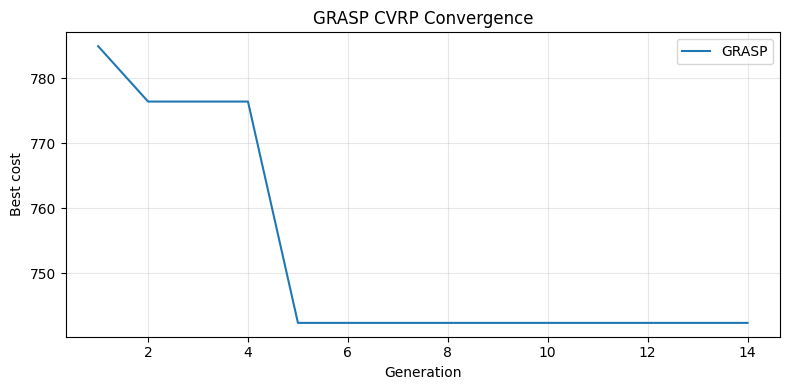

In [485]:
plot_convergence({"GRASP": cvrp_history}, title="GRASP CVRP Convergence")

#### GRASP Routes

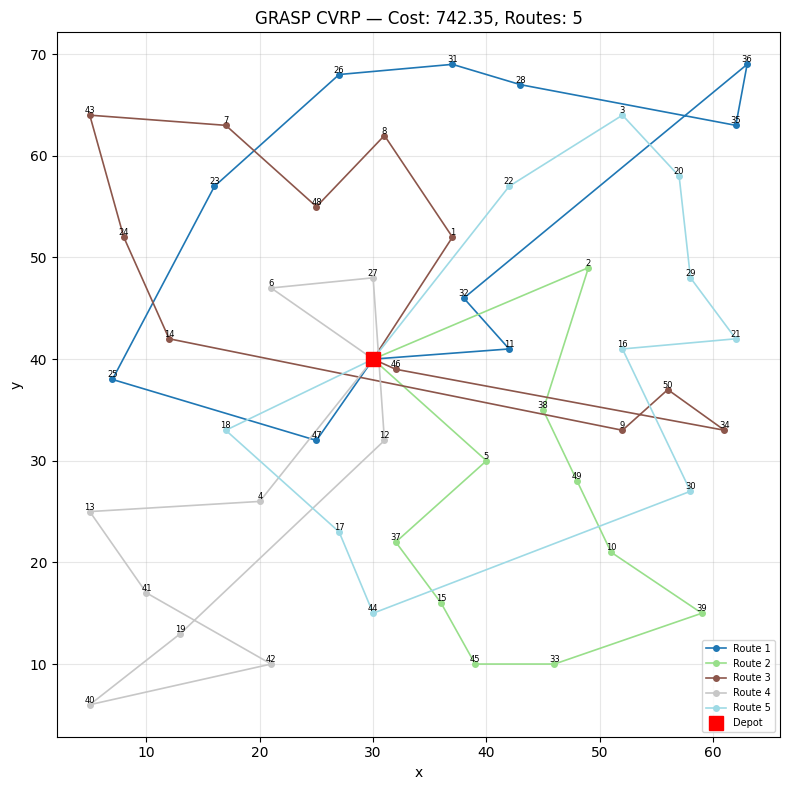

In [486]:
plot_routes(cvrp_routes, cvrp_data, title=f"GRASP CVRP — Cost: {cvrp_cost:.2f}, Routes: {len(cvrp_routes)}")

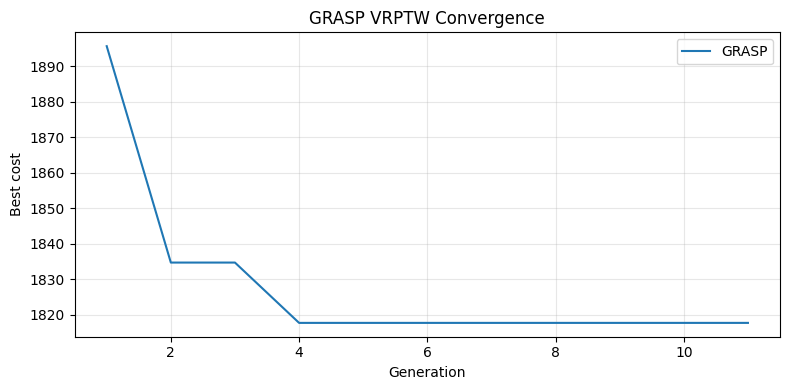

In [487]:
plot_convergence({"GRASP": vrptw_history}, title="GRASP VRPTW Convergence")

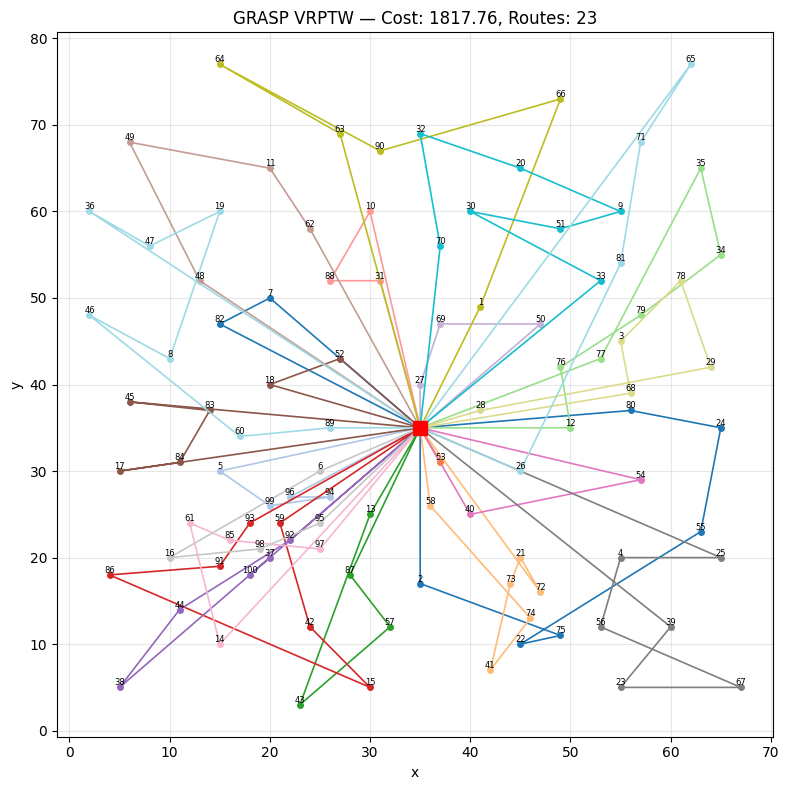

In [488]:
plot_routes(vrptw_routes, vrptw_data, title=f"GRASP VRPTW — Cost: {vrptw_cost:.2f}, Routes: {len(vrptw_routes)}")

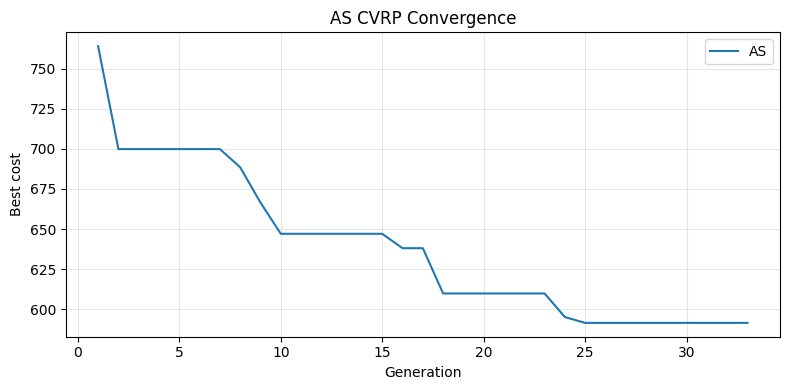

In [489]:
plot_convergence({"AS": as_cvrp_history}, title="AS CVRP Convergence")

##### AS Routes

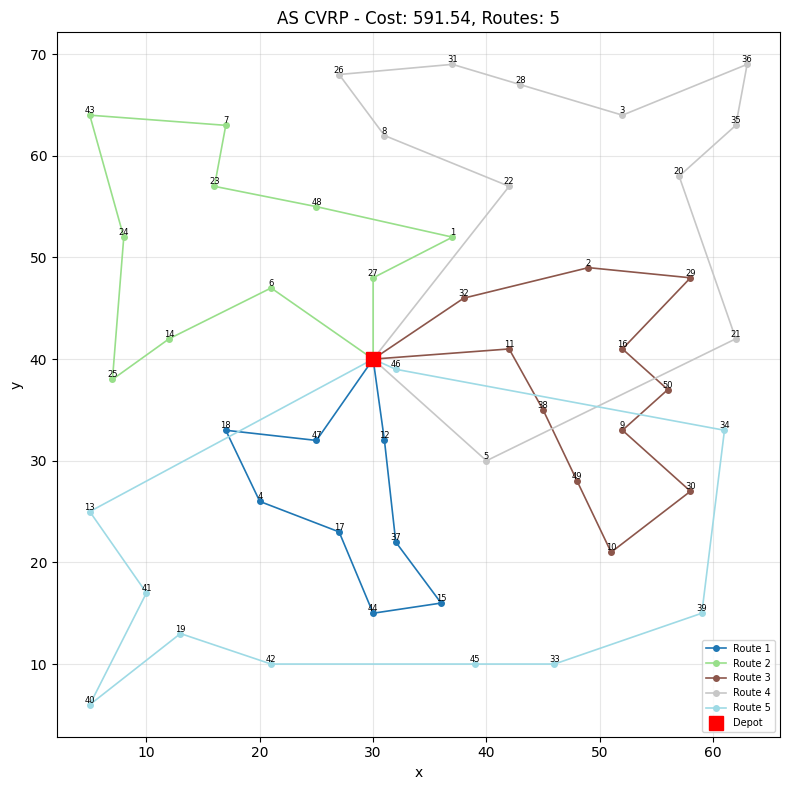

In [490]:
plot_routes(as_cvrp_routes, cvrp_data, title=f"AS CVRP - Cost: {as_cvrp_cost:.2f}, Routes: {len(as_cvrp_routes)}")

#### Convergence comparison

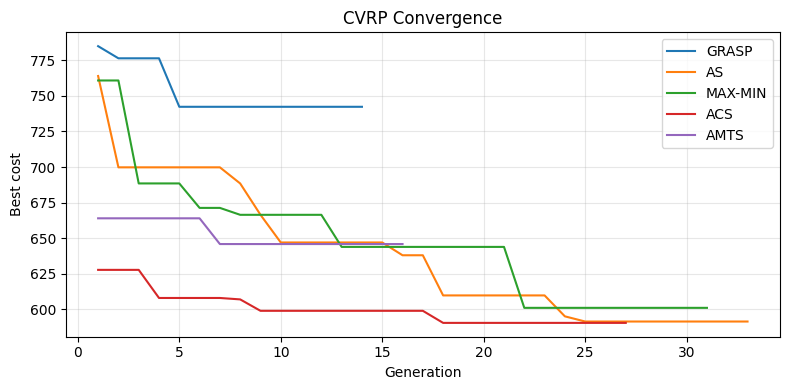

In [491]:
plot_convergence({"GRASP": cvrp_history, "AS": as_cvrp_history, "MAX-MIN": mm_as_cvrp_history, "ACS": acs_cvrp_history, "AMTS": amts_cvrp_history}, title="CVRP Convergence")

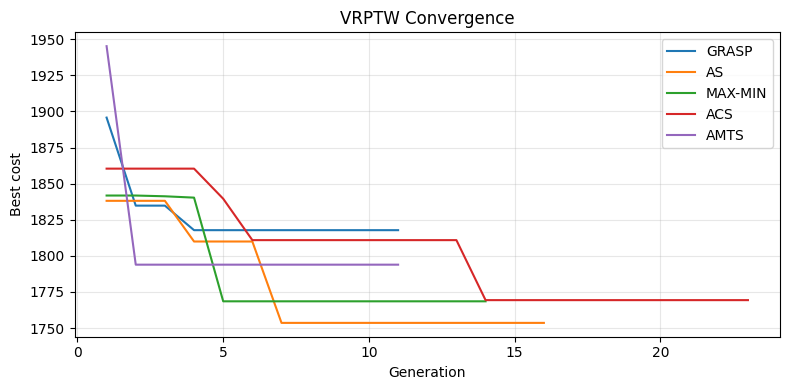

In [492]:
plot_convergence({"GRASP": vrptw_history, "AS": as_vrptw_history, "MAX-MIN": mm_as_vrptw_history, "ACS": acs_vrptw_history, "AMTS": amts_vrptw_history}, title="VRPTW Convergence")

### Parameter tuning

#### AS - Comparing alpha and beta

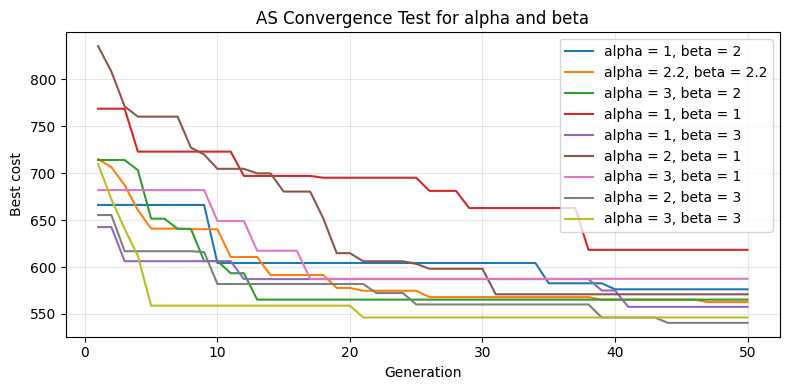

In [493]:
ant_system_a1_b2 = AntSystem(n_ants=20, alpha=1, beta=2, rho=0.1, criteria=[MaxGenerations(50)])
ant_system_a2p2_b2p2 = AntSystem(n_ants=20, alpha=2.2, beta=2.2, rho=0.1, criteria=[MaxGenerations(50)])
ant_system_a3_b2 = AntSystem(n_ants=20, alpha=3, beta=2, rho=0.1, criteria=[MaxGenerations(50)])
ant_system_a1_b1 = AntSystem(n_ants=20, alpha=1, beta=1, rho=0.1, criteria=[MaxGenerations(50)])
ant_system_a1_b3 = AntSystem(n_ants=20, alpha=1, beta=3, rho=0.1, criteria=[MaxGenerations(50)])
ant_system_a2_b1 = AntSystem(n_ants=20, alpha=2, beta=1, rho=0.1, criteria=[MaxGenerations(50)])
ant_system_a3_b1 = AntSystem(n_ants=20, alpha=3, beta=1, rho=0.1, criteria=[MaxGenerations(50)])
ant_system_a1_b3 = AntSystem(n_ants=20, alpha=1, beta=3, rho=0.1, criteria=[MaxGenerations(50)])
ant_system_a2_b3 = AntSystem(n_ants=20, alpha=2, beta=3, rho=0.1, criteria=[MaxGenerations(50)])
ant_system_a3_b3 = AntSystem(n_ants=20, alpha=3, beta=3, rho=0.1, criteria=[MaxGenerations(50)])

as_a1_b2_cvrp_routes, as_a1_b2_cvrp_cost, as_a1_b2_cvrp_history = ant_system_a1_b2.solve(cvrp_data)
as_a2p2_b2p2_cvrp_routes, as_a2p2_b2p2_cvrp_cost, as_a2p2_b2p2_cvrp_history = ant_system_a2p2_b2p2.solve(cvrp_data)
as_a3_b2_cvrp_routes, as_a3_b2_cvrp_cost, as_a3_b2_cvrp_history = ant_system_a3_b2.solve(cvrp_data)
as_a1_b1_cvrp_routes, as_a1_b1_cvrp_cost, as_a1_b1_cvrp_history = ant_system_a1_b1.solve(cvrp_data)
as_a1_b3_cvrp_routes, as_a1_b3_cvrp_cost, as_a1_b3_cvrp_history = ant_system_a1_b3.solve(cvrp_data)
as_a2_b1_cvrp_routes, as_a2_b1_cvrp_cost, as_a2_b1_cvrp_history = ant_system_a2_b1.solve(cvrp_data)
as_a3_b1_cvrp_routes, as_a3_b1_cvrp_cost, as_a3_b1_cvrp_history = ant_system_a3_b1.solve(cvrp_data)
as_a1_b3_cvrp_routes, as_a1_b3_cvrp_cost, as_a1_b3_cvrp_history = ant_system_a1_b3.solve(cvrp_data)
as_a2_b3_cvrp_routes, as_a2_b3_cvrp_cost, as_a2_b3_cvrp_history = ant_system_a2_b3.solve(cvrp_data)
as_a3_b3_cvrp_routes, as_a3_b3_cvrp_cost, as_a3_b3_cvrp_history = ant_system_a3_b3.solve(cvrp_data)

plot_convergence({
    "alpha = 1, beta = 2": as_a1_b2_cvrp_history, 
    "alpha = 2.2, beta = 2.2": as_a2p2_b2p2_cvrp_history, 
    "alpha = 3, beta = 2": as_a3_b2_cvrp_history,
    "alpha = 1, beta = 1": as_a1_b1_cvrp_history,
    "alpha = 1, beta = 3": as_a1_b3_cvrp_history,
    "alpha = 2, beta = 1": as_a2_b1_cvrp_history,
    "alpha = 3, beta = 1": as_a3_b1_cvrp_history,
    "alpha = 1, beta = 3": as_a1_b3_cvrp_history,
    "alpha = 2, beta = 3": as_a2_b3_cvrp_history,
    "alpha = 3, beta = 3": as_a3_b3_cvrp_history,
    }, "AS Convergence Test for alpha and beta")

#### ACS - Comparing alpha and beta

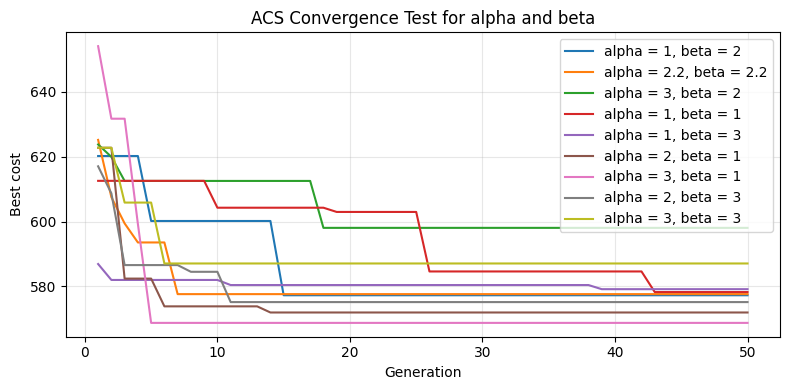

In [494]:
ant_colony_system_a1_b2 = AntColonySystem(n_ants=20, alpha=1, beta=2, rho=0.1, criteria=[MaxGenerations(50)])
ant_colony_system_a2p2_b2p2 = AntColonySystem(n_ants=20, alpha=2.2, beta=2.2, rho=0.1, criteria=[MaxGenerations(50)])
ant_colony_system_a3_b2 = AntColonySystem(n_ants=20, alpha=3, beta=2, rho=0.1, criteria=[MaxGenerations(50)])
ant_colony_system_a1_b1 = AntColonySystem(n_ants=20, alpha=1, beta=1, rho=0.1, criteria=[MaxGenerations(50)])
ant_colony_system_a1_b3 = AntColonySystem(n_ants=20, alpha=1, beta=3, rho=0.1, criteria=[MaxGenerations(50)])
ant_colony_system_a2_b1 = AntColonySystem(n_ants=20, alpha=2, beta=1, rho=0.1, criteria=[MaxGenerations(50)])
ant_colony_system_a3_b1 = AntColonySystem(n_ants=20, alpha=3, beta=1, rho=0.1, criteria=[MaxGenerations(50)])
ant_colony_system_a1_b3 = AntColonySystem(n_ants=20, alpha=1, beta=3, rho=0.1, criteria=[MaxGenerations(50)])
ant_colony_system_a2_b3 = AntColonySystem(n_ants=20, alpha=2, beta=3, rho=0.1, criteria=[MaxGenerations(50)])
ant_colony_system_a3_b3 = AntColonySystem(n_ants=20, alpha=3, beta=3, rho=0.1, criteria=[MaxGenerations(50)])

acs_a1_b2_cvrp_routes, acs_a1_b2_cvrp_cost, acs_a1_b2_cvrp_history = ant_colony_system_a1_b2.solve(cvrp_data)
acs_a2p2_b2p2_cvrp_routes, acs_a2p2_b2p2_cvrp_cost, acs_a2p2_b2p2_cvrp_history = ant_colony_system_a2p2_b2p2.solve(cvrp_data)
acs_a3_b2_cvrp_routes, acs_a3_b2_cvrp_cost, acs_a3_b2_cvrp_history = ant_colony_system_a3_b2.solve(cvrp_data)
acs_a1_b1_cvrp_routes, acs_a1_b1_cvrp_cost, acs_a1_b1_cvrp_history = ant_colony_system_a1_b1.solve(cvrp_data)
acs_a1_b3_cvrp_routes, acs_a1_b3_cvrp_cost, acs_a1_b3_cvrp_history = ant_colony_system_a1_b3.solve(cvrp_data)
acs_a2_b1_cvrp_routes, acs_a2_b1_cvrp_cost, acs_a2_b1_cvrp_history = ant_colony_system_a2_b1.solve(cvrp_data)
acs_a3_b1_cvrp_routes, acs_a3_b1_cvrp_cost, acs_a3_b1_cvrp_history = ant_colony_system_a3_b1.solve(cvrp_data)
acs_a1_b3_cvrp_routes, acs_a1_b3_cvrp_cost, acs_a1_b3_cvrp_history = ant_colony_system_a1_b3.solve(cvrp_data)
acs_a2_b3_cvrp_routes, acs_a2_b3_cvrp_cost, acs_a2_b3_cvrp_history = ant_colony_system_a2_b3.solve(cvrp_data)
acs_a3_b3_cvrp_routes, acs_a3_b3_cvrp_cost, acs_a3_b3_cvrp_history = ant_colony_system_a3_b3.solve(cvrp_data)

plot_convergence({
    "alpha = 1, beta = 2": acs_a1_b2_cvrp_history, 
    "alpha = 2.2, beta = 2.2": acs_a2p2_b2p2_cvrp_history, 
    "alpha = 3, beta = 2": acs_a3_b2_cvrp_history,
    "alpha = 1, beta = 1": acs_a1_b1_cvrp_history,
    "alpha = 1, beta = 3": acs_a1_b3_cvrp_history,
    "alpha = 2, beta = 1": acs_a2_b1_cvrp_history,
    "alpha = 3, beta = 1": acs_a3_b1_cvrp_history,
    "alpha = 1, beta = 3": acs_a1_b3_cvrp_history,
    "alpha = 2, beta = 3": acs_a2_b3_cvrp_history,
    "alpha = 3, beta = 3": acs_a3_b3_cvrp_history,
    }, "ACS Convergence Test for alpha and beta")

### AS - Comparing Normal vs Elitist vs Rank-based Solution Selection

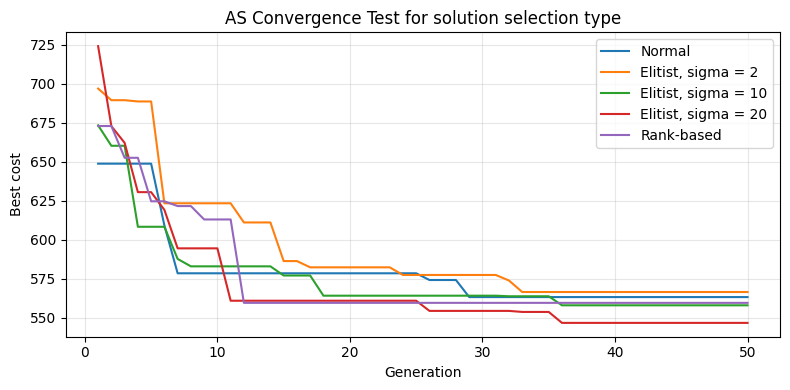

In [495]:
ant_system_normal = AntSystem(n_ants=20, alpha=2.2, beta=2.2, rho=0.1, criteria=[MaxGenerations(50)], solution_selection_type="normal")
ant_system_elitist_s2 = AntSystem(n_ants=20, alpha=2.2, beta=2.2, rho=0.1, criteria=[MaxGenerations(50)], solution_selection_type="eas", sigma=2)
ant_system_elitist_s10 = AntSystem(n_ants=20, alpha=2.2, beta=2.2, rho=0.1, criteria=[MaxGenerations(50)], solution_selection_type="eas", sigma=10)
ant_system_elitist_s20 = AntSystem(n_ants=20, alpha=2.2, beta=2.2, rho=0.1, criteria=[MaxGenerations(50)], solution_selection_type="eas", sigma=20)
ant_system_rank_based = AntSystem(n_ants=20, alpha=2.2, beta=2.2, rho=0.1, criteria=[MaxGenerations(50)], solution_selection_type="rankbased")

as_normal_cvrp_routes, as_normal_cvrp_cost, as_normal_cvrp_history = ant_system_normal.solve(cvrp_data)
as_elitist_s2_cvrp_routes, as_elitist_s2_cvrp_cost, as_elitist_s2_cvrp_history = ant_system_elitist_s2.solve(cvrp_data)
as_elitist_s10_cvrp_routes, as_elitist_s10_cvrp_cost, as_elitist_s10_cvrp_history = ant_system_elitist_s10.solve(cvrp_data)
as_elitist_s20_cvrp_routes, as_elitist_s20_cvrp_cost, as_elitist_s20_cvrp_history = ant_system_elitist_s20.solve(cvrp_data)
as_rank_based_cvrp_routes, as_rank_based_cvrp_cost, as_rank_based_cvrp_history = ant_system_rank_based.solve(cvrp_data)

plot_convergence({
    "Normal": as_normal_cvrp_history, 
    "Elitist, sigma = 2": as_elitist_s2_cvrp_history,
    "Elitist, sigma = 10": as_elitist_s10_cvrp_history,
    "Elitist, sigma = 20": as_elitist_s20_cvrp_history,
    "Rank-based": as_rank_based_cvrp_history,
    }, "AS Convergence Test for solution selection type")

### AS - Comparing different rho values

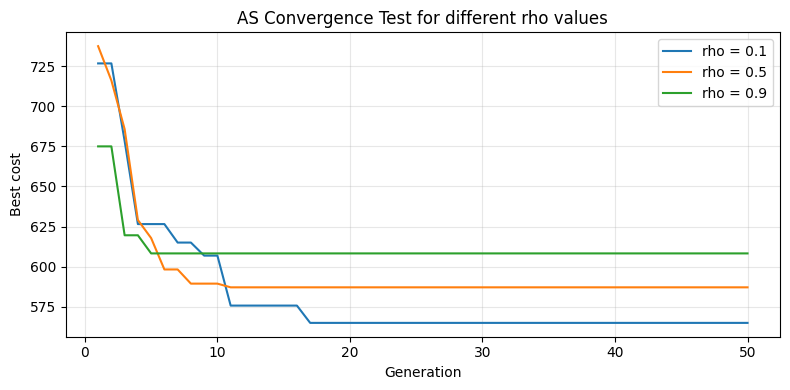

In [496]:
ant_system_r0p1 = AntSystem(n_ants=20, alpha=2.2, beta=2.2, rho=0.1, criteria=[MaxGenerations(50)])
ant_system_r0p5 = AntSystem(n_ants=20, alpha=2.2, beta=2.2, rho=0.5, criteria=[MaxGenerations(50)])
ant_system_r0p9 = AntSystem(n_ants=20, alpha=2.2, beta=2.2, rho=0.9, criteria=[MaxGenerations(50)])

_, _, as_r0p1_cvrp_history = ant_system_r0p1.solve(cvrp_data)
_, _, as_r0p5_cvrp_history = ant_system_r0p5.solve(cvrp_data)
_, _, as_r0p9_cvrp_history = ant_system_r0p9.solve(cvrp_data)

plot_convergence({
    "rho = 0.1": as_r0p1_cvrp_history, 
    "rho = 0.5": as_r0p5_cvrp_history, 
    "rho = 0.9": as_r0p9_cvrp_history,
    }, "AS Convergence Test for different rho values")

### AS - Comparing different numbers of ants

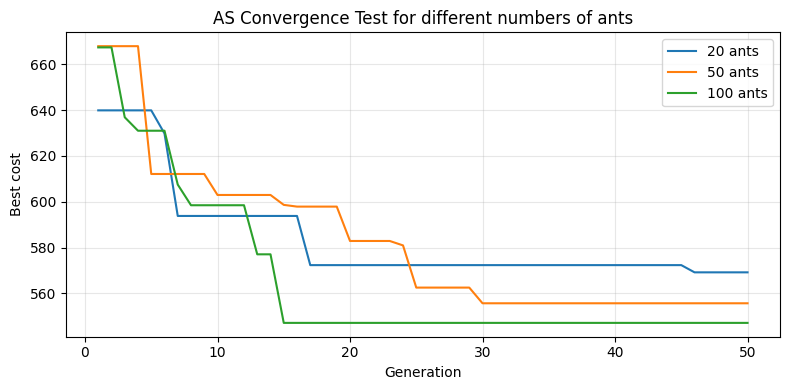

In [497]:
ant_system_ants_20 = AntSystem(n_ants=20, alpha=2.2, beta=2.2, rho=0.1, criteria=[MaxGenerations(50)])
ant_system_ants_50 = AntSystem(n_ants=50, alpha=2.2, beta=2.2, rho=0.1, criteria=[MaxGenerations(50)])
ant_system_ants_100 = AntSystem(n_ants=100, alpha=2.2, beta=2.2, rho=0.1, criteria=[MaxGenerations(50)])

_, _, as_ants20_cvrp_history = ant_system_ants_20.solve(cvrp_data)
_, _, as_ants50_cvrp_history = ant_system_ants_50.solve(cvrp_data)
_, _, as_ants100_cvrp_history = ant_system_ants_100.solve(cvrp_data)

plot_convergence({
    "20 ants": as_ants20_cvrp_history, 
    "50 ants": as_ants50_cvrp_history, 
    "100 ants": as_ants100_cvrp_history,
    }, "AS Convergence Test for different numbers of ants")

### AS - Comparing different number of generations

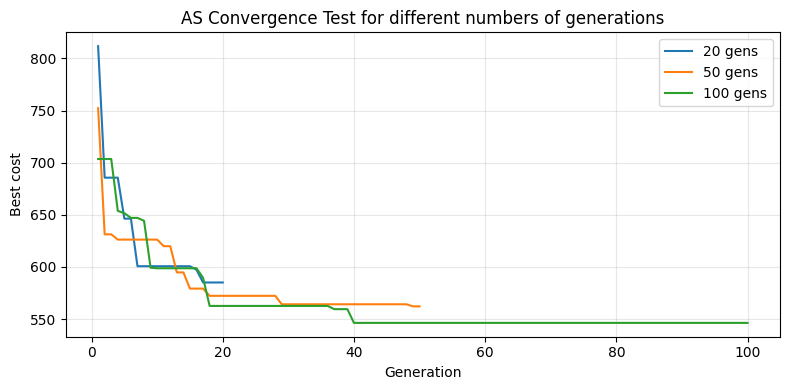

In [498]:
ant_system_gen_20 = AntSystem(n_ants=20, alpha=2.2, beta=2.2, rho=0.1, criteria=[MaxGenerations(20)])
ant_system_gen_50 = AntSystem(n_ants=20, alpha=2.2, beta=2.2, rho=0.1, criteria=[MaxGenerations(50)])
ant_system_gen_100 = AntSystem(n_ants=20, alpha=2.2, beta=2.2, rho=0.1, criteria=[MaxGenerations(100)])

_, _, as_gen20_cvrp_history = ant_system_gen_20.solve(cvrp_data)
_, _, as_gen50_cvrp_history = ant_system_gen_50.solve(cvrp_data)
_, _, as_gen100_cvrp_history = ant_system_gen_100.solve(cvrp_data)

plot_convergence({
    "20 gens": as_gen20_cvrp_history, 
    "50 gens": as_gen50_cvrp_history, 
    "100 gens": as_gen100_cvrp_history,
    }, "AS Convergence Test for different numbers of generations")

### GRASP - Comparing different values for alpha

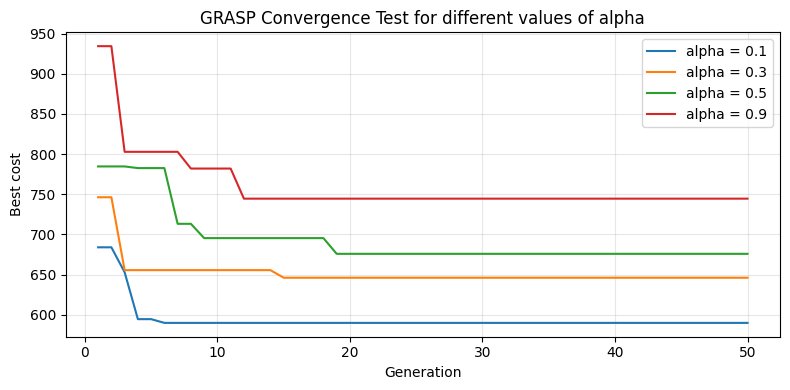

In [499]:
grasp_alpha_0p1 = GraspSolver(alpha=0.1, criteria=[MaxGenerations(50)])
grasp_alpha_0p3 = GraspSolver(alpha=0.3, criteria=[MaxGenerations(50)])
grasp_alpha_0p5 = GraspSolver(alpha=0.5, criteria=[MaxGenerations(50)])
grasp_alpha_0p9 = GraspSolver(alpha=0.9, criteria=[MaxGenerations(50)])

_, _, grasp_alpha_0p1_cvrp_history = grasp_alpha_0p1.solve(cvrp_data)
_, _, grasp_alpha_0p3_cvrp_history = grasp_alpha_0p3.solve(cvrp_data)
_, _, grasp_alpha_0p5_cvrp_history = grasp_alpha_0p5.solve(cvrp_data)
_, _, grasp_alpha_0p9_cvrp_history = grasp_alpha_0p9.solve(cvrp_data)

plot_convergence({
    "alpha = 0.1": grasp_alpha_0p1_cvrp_history,
    "alpha = 0.3": grasp_alpha_0p3_cvrp_history,
    "alpha = 0.5": grasp_alpha_0p5_cvrp_history,
    "alpha = 0.9": grasp_alpha_0p9_cvrp_history,
}, "GRASP Convergence Test for different values of alpha")

### GRASP - Comparing different numbers of generations

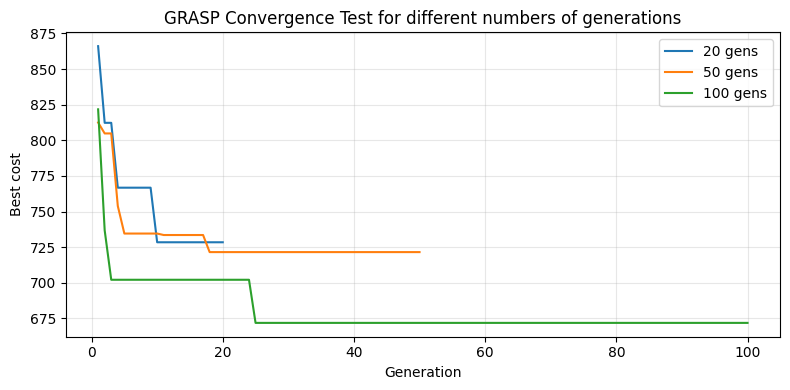

In [500]:
grasp_gen_20 = GraspSolver(criteria=[MaxGenerations(20)])
grasp_gen_50 = GraspSolver(criteria=[MaxGenerations(50)])
grasp_gen_100 = GraspSolver(criteria=[MaxGenerations(100)])

_, _, grasp_gen20_cvrp_history = grasp_gen_20.solve(cvrp_data)
_, _, grasp_gen50_cvrp_history = grasp_gen_50.solve(cvrp_data)
_, _, grasp_gen100_cvrp_history = grasp_gen_100.solve(cvrp_data)

plot_convergence({
    "20 gens": grasp_gen20_cvrp_history, 
    "50 gens": grasp_gen50_cvrp_history, 
    "100 gens": grasp_gen100_cvrp_history,
    }, "GRASP Convergence Test for different numbers of generations")

# Results

- alpha = 0.1 produced the best solution cost for the GRASP algorithm.

- rho = 0.1 produced the best solution cost for the Ant System algorithm.

- parameter tuning for alpha, beta, the solution selection method, and the number of ants did not significantly improve the results, because the performance of the ACO solvers varied between different executions due to randomness.

- changing the number of generations did not consistently improve the results either, since the speed of convergence mainly depended on the random behavior of the algorithm.